# Example of quantification of intracellular perturbations and growth inhibition for CJW7753 treated cells

__Steps__:
1. Download zip folder from BioStudies S-BIAD1823 for a given experiment/condition and extract the data. In this example, we will process data from 'CJW7753_CecA_1uM_rep1.zip'
2. Run 'import_processing_code.py' and curation functions 'post_processing_curation_functions.py' to obtain curated dataframes, as explained in '1_import_curation_single-cell_analysis.ipynb'
3. Import curated dataframes, align trajectories by SCF, compute normalize growth rates, plot ensemble SCF, NC ratio, mTagBFP2 signal vs time, and SCF peak time vs growth arrest

__Requirements on how to run__:
1. This notebook assumes the OmniSegger-processed extracted file data folder, here 'CJW7753_CecA_1uM_rep1', lives in the same folder as the notebook
2. The function libraries 'analysis_functions_library.py', 'get_permeabilization_time.py', 'multi_scale_derivative.py', 'nucleoid_cell_length.py', and 'time_alignment.py' are pulled from the repository folder '2_singlecell_microwells'

__Code underlying data and figures__:
- Single-cell data in PDMS microwells, strain CJW7753, to monitor intracellular perturbations of ribosomes and DNA
- Figures 3 and S4

### 1. Import curated dataframes, align trajectories, and plot features

Run time: < 10 min

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import numpy as np
import os
from scipy import io
import skimage
import warnings
import re
import time


"""
Import analysis functions library
"""
import sys
from pathlib import Path
sys.path.append(str(Path("../../2_singlecell_microwells").resolve()))
from analysis_functions_library import *

sys.path.append(str(Path("../../2_singlecell_microwells/membrane_permeabilization").resolve()))
from get_permeabilization_time import *
from multi_scale_derivative import *

sys.path.append(str(Path("../../2_singlecell_microwells/intracellular_perturbation").resolve()))
from nucleoid_cell_length import *

sys.path.append(str(Path("../../2_singlecell_microwells/intracellular_perturbation").resolve()))
from time_alignment import *

px_size = 0.065841  # um/px   (pixel size, 100x)


In [2]:
experiment_path = "CJW7753_CecA_1uM_rep1"     # -> extracted from CJW7753_CecA_1uM_rep1/
exp_name = experiment_path   # usual exp_name format is 'Strain_AMP_concentration_replicate#'
AMP_name = 'CecA_1uM'     # AMP name and concentration

# read fr_inj from the notes 
notes_file = next(Path(experiment_path).glob("notes_*.txt"))
print(notes_file.read_text())   # check when AMP was injected 'frame xx/yy'

Exp1) 241009, CJW7753 (0.2% arabinose, overnight)

37degC, M9GluCAAT (0.2% Glu, 0.4% CAA)

During acquisition: only 0.2% arabinose

CellTak:
- 50uL, 5min, of CellTak. 3x MQ wash.
- 0.5uL, OD=0.1, 5min, in M9GluCAAT. Quick medium wash.


Treatments/pos:
xy07-09: CJW7753 + CecA 1uM --> injected at frame 21/22

Comments:
- Good



In [3]:
import glob
'''--- Import curated dataframe from local output_2 ---'''
output_path = experiment_path + '/output_2'
df_files = sorted(glob.glob(output_path + '/*cell_features_df_first_curation*.pkl'))

df = pd.DataFrame()
for f in df_files:
    sub = pd.read_pickle(f)
    if len(sub) == 0:
        continue
    print('Loaded N=' + str(sub['cell_id'].nunique()) + ' cells from ' + os.path.basename(f))
    df = pd.concat([df, sub])

df['AMP'] = AMP_name

Loaded N=25 cells from xy07_CJW7753_CecA_1uM_rep1_cell_features_df_first_curation.pkl
Loaded N=21 cells from xy08_CJW7753_CecA_1uM_rep1_cell_features_df_first_curation.pkl
Loaded N=14 cells from xy09_CJW7753_CecA_1uM_rep1_cell_features_df_first_curation.pkl


In [4]:
window_sizes = [3, 5, 7, 9, 11]  # Must be odd
threshold_strict = 0
threshold_stable = 0.005
threshold_strict_2 = 0.01
threshold_stable_2 = 0.012
stable_window = 20
weight_mode = [5,8,10,8,5]

polyorder = 2
normalized = True  # use (1/A)*dA/dt

df = apply_weighted_derivative_detection(
    df, 
    window_sizes=window_sizes,
    threshold_strict=threshold_strict, 
    threshold_stable = threshold_stable,
    threshold_strict_2=threshold_strict_2, 
    threshold_stable_2 = threshold_stable_2,
    stable_window = stable_window,
    polyorder=polyorder,
    weight_mode=weight_mode,
    normalized=normalized
)


In [5]:
df.columns

Index(['cell_id', 'frame', 'time_min', 'area', 'exp', 'rep', 'xy', 'fr_inj',
       'BB', 'birth', 'death', 'motherID', 'sisterID', 'daughterID',
       'daughters', 'edge_flag', 'bkg_sub', 'mean_fluor1', 'mean_fluor2',
       'mean_fluor3', 'mean_phase', 'mean_mask_fluor1', 'area_mask_fluor1',
       'area_mask_ratio_fluor1', 'mean_mask_fluor2', 'area_mask_fluor2',
       'area_mask_ratio_fluor2', 'mean_mask_fluor3', 'area_mask_fluor3',
       'area_mask_ratio_fluor3', 'SCF_f12', 'SCF_f13', 'SCF_f23', 'area_um',
       'area_smooth', 'time_min_aligned', 'time_min_offs', 'gr_smooth', 'gr',
       'gr_smooth_norm', 'AMP', 'combined_deriv', 'event_time',
       'offset_event_time', 'event_time_2', 'offset_event_time_2'],
      dtype='object')

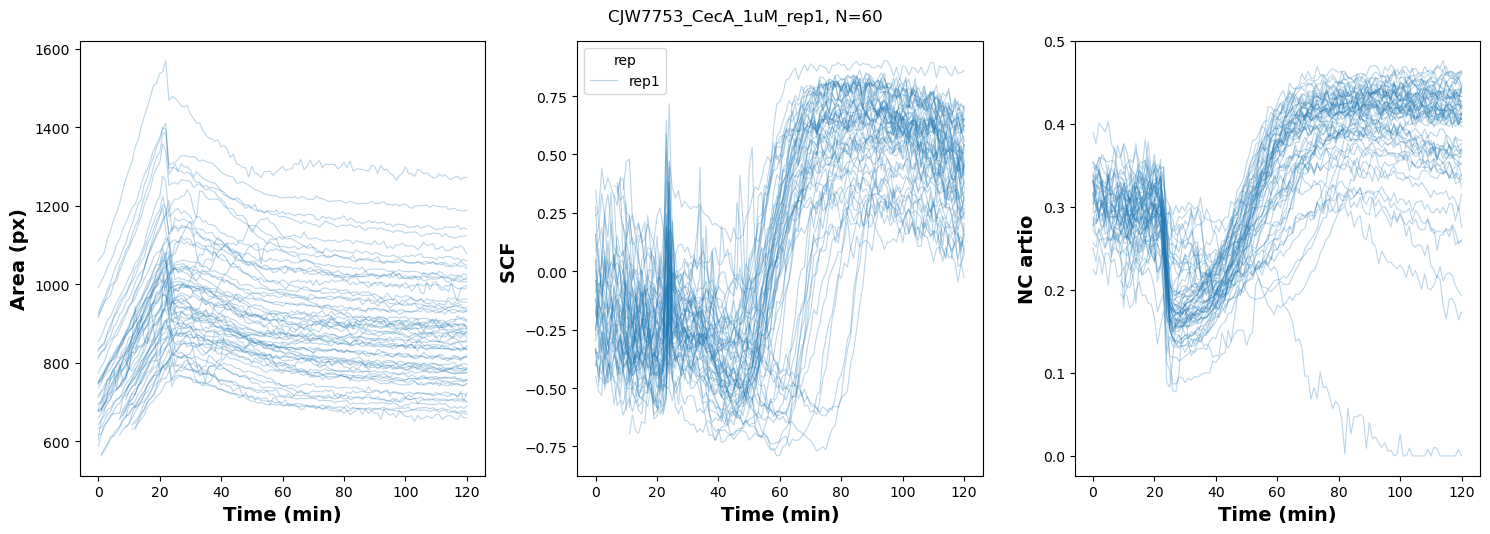

In [6]:

''''
Plot cell area, NC ratio, and SCF
'''

fig = plt.figure(figsize=(15, 10))
fig.suptitle(exp_name + ', N=' + str(len(df['cell_id'].unique().tolist())))

ax1 = fig.add_subplot(2,3,1)
x_var = 'time_min'
# x_var = 't_align_area'              # to align by max area
# x_var = 't_align_SCF_f12'             # to align by SCF
# x_var = 't_align_SCF_smooth'
# x_var = 't_align_mask_ratio_fluor2_smooth'    # to align by NC ratio

y_var = 'area'
sns.lineplot(df, x=x_var, y=y_var, estimator=None,
             lw=0.8, units="cell_id", alpha=0.3)
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('Area (px)', fontsize=14, fontweight='bold')

ax1 = fig.add_subplot(2,3,3)
# x_var = 'time_min_aligned'
y_var = 'area_mask_ratio_fluor2'
sns.lineplot(df, x=x_var, y=y_var, estimator=None,
             lw=0.8, units="cell_id", alpha=0.3)
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('NC ratio (area)', fontsize=14, fontweight='bold')


ax1 = fig.add_subplot(2,3,2)
y_var = 'SCF_f12'
sns.lineplot(df, x=x_var, y=y_var, estimator=None,
             lw=0.8, units="cell_id", alpha=0.3, hue = 'rep')
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('SCF ', fontsize=14, fontweight='bold')

plt.tight_layout()  
plt.show()

__Time alignment by peak area__

In [7]:
df = time_align(df, markers=['area',  'SCF_f12', 'area_mask_ratio_fluor2'], peak_values=[
                'max', 'max', 'min'], time_axis='time_min', window=[0,80])

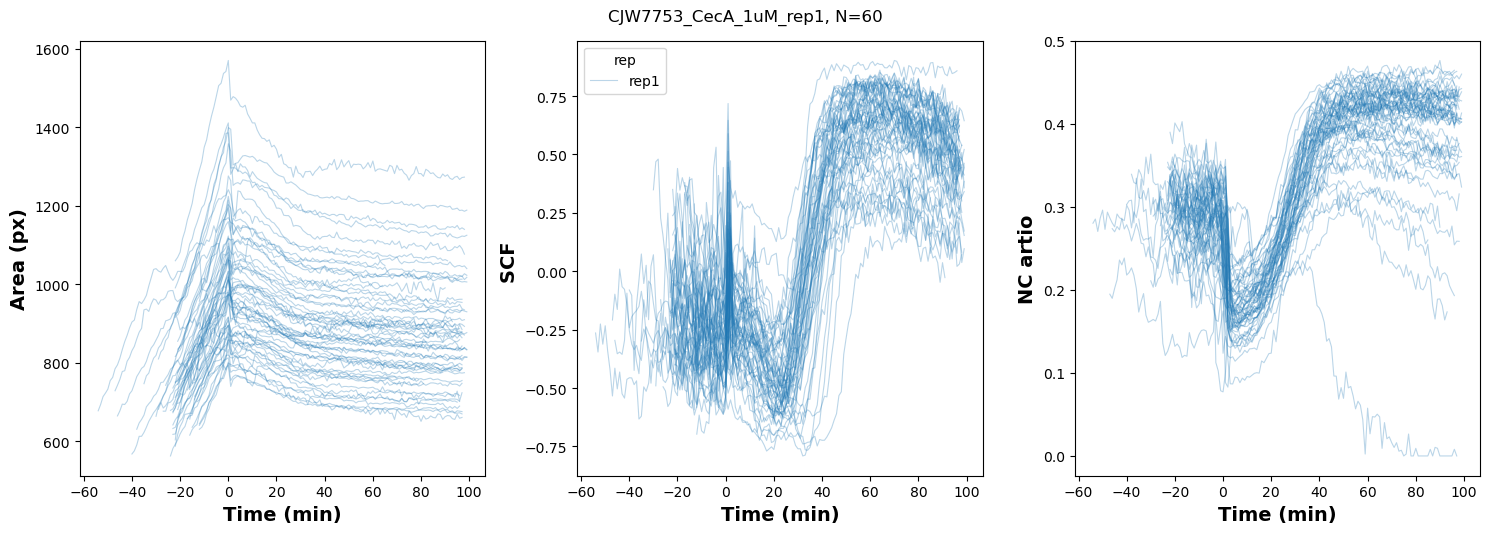

In [8]:
''''
Plot cell area, NC ratio, and SCF
'''

fig = plt.figure(figsize=(15, 10))
fig.suptitle(exp_name + ', N=' + str(len(df['cell_id'].unique().tolist())))

ax1 = fig.add_subplot(2,3,1)
# x_var = 'time_min'
x_var = 't_align_area'              # to align by max area
# x_var = 't_align_SCF_f12'             # to align by SCF
# x_var = 't_align_SCF_smooth'
# x_var = 't_align_mask_ratio_fluor2_smooth'    # to align by NC ratio

y_var = 'area'
sns.lineplot(df, x=x_var, y=y_var, estimator=None,
             lw=0.8, units="cell_id", alpha=0.3)
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('Area (px)', fontsize=14, fontweight='bold')

ax1 = fig.add_subplot(2,3,2)
y_var = 'SCF_f12'
sns.lineplot(df, x=x_var, y=y_var, estimator=None,
             lw=0.8, units="cell_id", alpha=0.3, hue = 'rep')
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('SCF ', fontsize=14, fontweight='bold')

ax1 = fig.add_subplot(2,3,3)
y_var = 'area_mask_ratio_fluor2'
sns.lineplot(df, x=x_var, y=y_var, estimator=None,
             lw=0.8, units="cell_id", alpha=0.3)
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('NC ratio (area)', fontsize=14, fontweight='bold')


plt.tight_layout()  
plt.show()

__Time alignment by peak SCF__

In [9]:
df = time_align(df, markers=['area',  'SCF_f12', 'area_mask_ratio_fluor2'], peak_values=[
                'max', 'max', 'min'], time_axis='t_align_area', window=[-5,5])

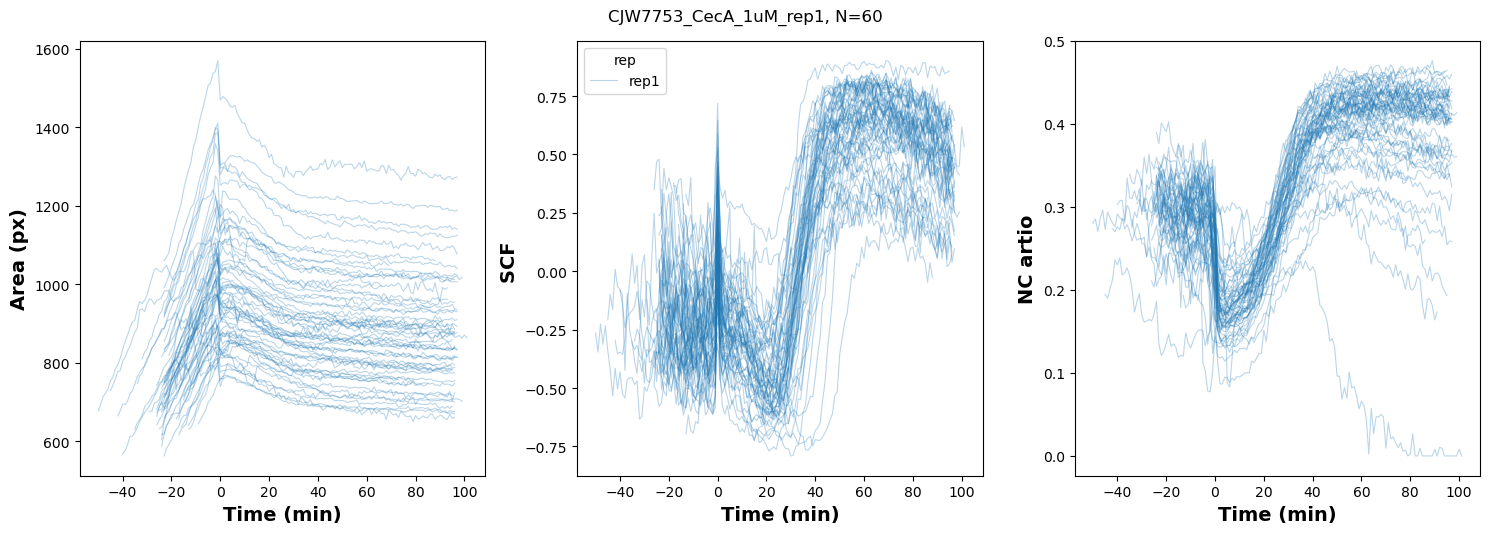

In [10]:
''''
Plot cell area, NC ratio, and SCF
'''

fig = plt.figure(figsize=(15, 10))
fig.suptitle(exp_name + ', N=' + str(len(df['cell_id'].unique().tolist())))

ax1 = fig.add_subplot(2,3,1)
# x_var = 'time_min'
# x_var = 't_align_area'              # to align by max area
x_var = 't_align_SCF_f12'             # to align by SCF
# x_var = 't_align_SCF_smooth'
# x_var = 't_align_mask_ratio_fluor2_smooth'    # to align by NC ratio

y_var = 'area'
sns.lineplot(df, x=x_var, y=y_var, estimator=None,
             lw=0.8, units="cell_id", alpha=0.3)
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('Area (px)', fontsize=14, fontweight='bold')

ax1 = fig.add_subplot(2,3,2)
y_var = 'SCF_f12'
sns.lineplot(df, x=x_var, y=y_var, estimator=None,
             lw=0.8, units="cell_id", alpha=0.3, hue = 'rep')
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('SCF ', fontsize=14, fontweight='bold')

ax1 = fig.add_subplot(2,3,3)
y_var = 'area_mask_ratio_fluor2'
sns.lineplot(df, x=x_var, y=y_var, estimator=None,
             lw=0.8, units="cell_id", alpha=0.3)
plt.xlabel('Time (min)', fontsize=14, fontweight='bold')
plt.ylabel('NC ratio (area)', fontsize=14, fontweight='bold')


plt.tight_layout()  
plt.show()

__Export aligned dataframe__

In [11]:
output_folder = 'output_2'
df_name = '_cell_features_df_time_aligned'

save_dict_path = experiment_path + '/' + output_folder
if not os.path.exists(save_dict_path):
    os.makedirs(save_dict_path)

count = 0
for pos in df['xy'].unique():
    df_basename = 'xy' + pos + '_' + exp_name + df_name
    sub_df_temp = df[df['xy'] == pos]
    sub_df_temp.to_pickle(save_dict_path + '/' + df_basename + '.pkl')
    N = np.size(sub_df_temp['cell_id'].unique())
    count += N
    print('Saved df with N=' + str(N) + ' at pos ' + pos)
print('Total cells is: ' + str(count))

Saved df with N=21 at pos 08
Saved df with N=14 at pos 09
Saved df with N=25 at pos 07
Total cells is: 60


## Compute medial axis to get cell length and NC ratio = arc length of nucleoid / arc length of cell

Run time ~ 1s per frame per cell

In [12]:
import glob
'''--- Import curated dataframe from local output_2 ---'''
output_path = experiment_path + '/output_2'
df_files = sorted(glob.glob(output_path + '/*cell_features_df_time_aligned*.pkl'))

df = pd.DataFrame()
for f in df_files:
    sub = pd.read_pickle(f)
    if len(sub) == 0:
        continue
    print('Loaded N=' + str(sub['cell_id'].nunique()) + ' cells from ' + os.path.basename(f))
    df = pd.concat([df, sub])

df['AMP'] = AMP_name

Loaded N=25 cells from xy07_CJW7753_CecA_1uM_rep1_cell_features_df_time_aligned.pkl
Loaded N=21 cells from xy08_CJW7753_CecA_1uM_rep1_cell_features_df_time_aligned.pkl
Loaded N=14 cells from xy09_CJW7753_CecA_1uM_rep1_cell_features_df_time_aligned.pkl


In [23]:
aug = 20
fr = 1    # [min] time between frame
px_size = 0.065841  # um/px   (pixel size in alpha scope, 100x)
save = False
overwrite = True
plot = True
ch_list = ['phase', 'fluor1', 'fluor2','fluor3']
ch_fluor_list = [s for s in ch_list if 'fluor' in s]
exp_name = 'CJW7753_CecA_1uM_rep1'

No medial axis already computed
Importing channels dictionary for CJW7753_CecA_1uM_rep1 at position xy09...
Importing dataframe CJW7753_CecA_1uM_rep1 at position xy09...
..Computing medial axis for cells at position xy09 for experiment CJW7753_CecA_1uM_rep1
cell0000001_xy09_CJW7753_CecA_1uM_rep1


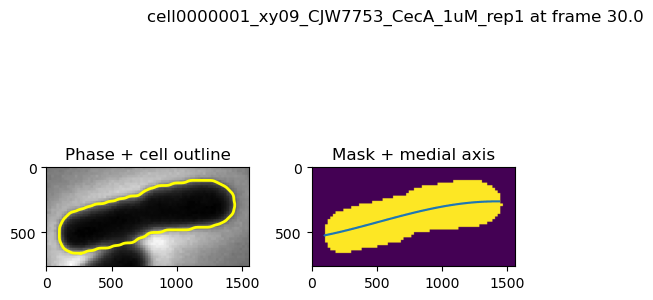

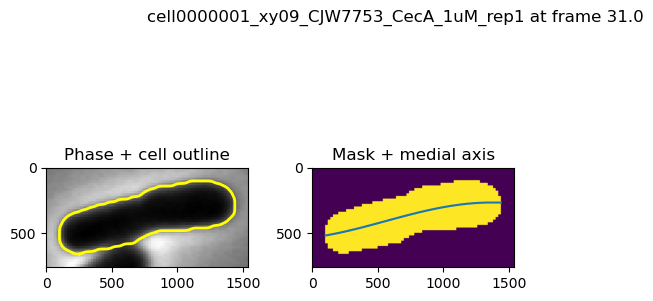

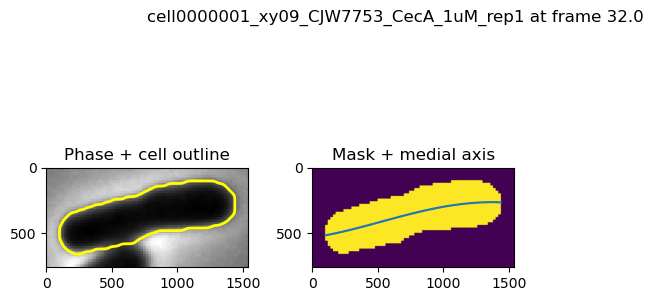

No medial axis already computed
Importing channels dictionary for CJW7753_CecA_1uM_rep1 at position xy07...
Importing dataframe CJW7753_CecA_1uM_rep1 at position xy07...
..Computing medial axis for cells at position xy07 for experiment CJW7753_CecA_1uM_rep1
cell0000002_xy07_CJW7753_CecA_1uM_rep1


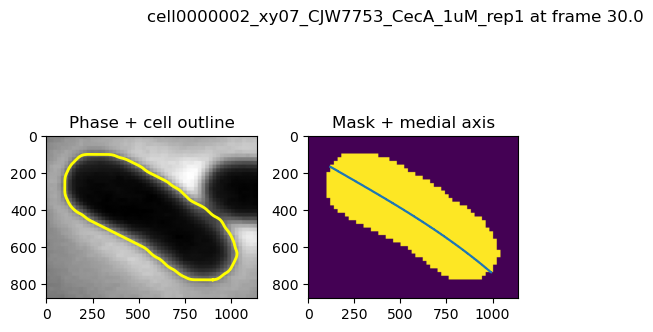

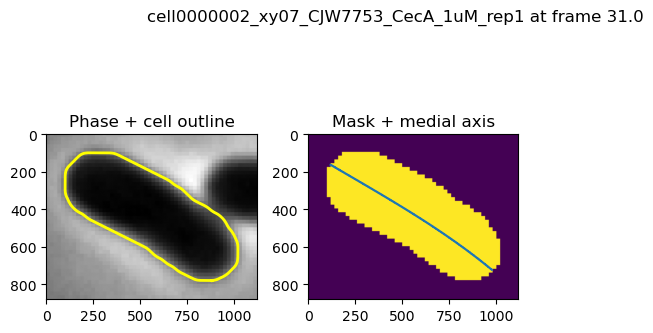

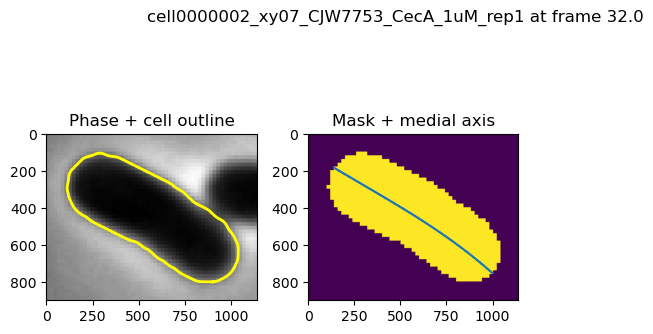

No medial axis already computed
Importing channels dictionary for CJW7753_CecA_1uM_rep1 at position xy08...
Importing dataframe CJW7753_CecA_1uM_rep1 at position xy08...
..Computing medial axis for cells at position xy08 for experiment CJW7753_CecA_1uM_rep1
cell0000001_xy08_CJW7753_CecA_1uM_rep1


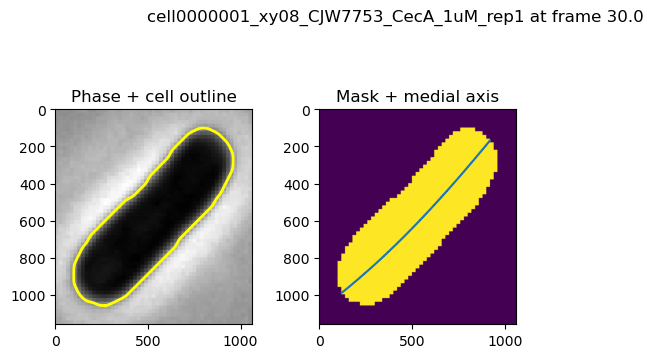

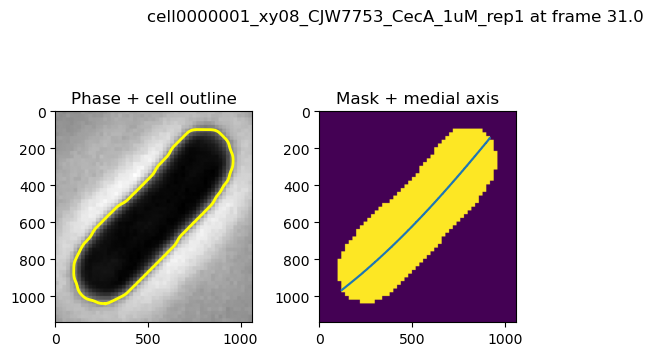

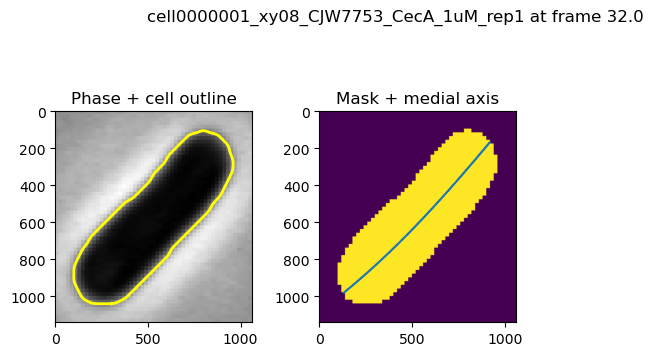

In [24]:
'''Medial-axis computation — single experiment, loop over positions only'''
rep = 'rep_1'                                          # single replicate for this demo
pos_list = ['xy' + s for s in df['xy'].unique().tolist()]

for pos in pos_list:
    folder_path = experiment_path + '/' + pos           # path to position
    cells_path = folder_path + "/cell"
    mask_path = folder_path + '/masks'
    phase_path = folder_path + '/phase'
    output_path = experiment_path + '/output'
    output_2_path = experiment_path + '/output_2'
    output_medial_path = experiment_path + '/output_medial'

    if os.path.exists(output_medial_path) and not overwrite:
        medial_list = os.listdir(output_medial_path)
        if len([s for s in medial_list if pos in s]) > 0:
            medial_axis_df_name = [s for s in medial_list if pos in s and 'medial' in s][0]
            if len(medial_axis_df_name) > 0:
                print('Medial axes already computed for ' + pos + ', ' + exp_name)
                continue
    else:
        print('No medial axis already computed')
        medial_list = []
    if os.path.exists(output_path) and os.path.exists(output_2_path):
        if len([s for s in os.listdir(output_path) if pos in s]) == 0:
            continue

    if os.path.exists(cells_path):
        cells_list = os.listdir(cells_path)
    else:
        continue
    if len(cells_list) == 0:
        continue

    masks_list = os.listdir(mask_path)
    phase_list = os.listdir(phase_path)

    '''Import json and pickle files'''
    print('Importing channels dictionary for ' + exp_name + ' at position ' + pos + '...')
    with open(output_path + '/' + pos + '_' + exp_name + '_cell_ch_bkg_sub.pkl', 'rb') as pickle_file:
        cell_ch_dict = pickle.load(pickle_file)

    df_list = os.listdir(output_2_path)
    df_name = [s for s in df_list if 'first_curation' in s and pos in s]
    if len(df_name) == 0:
        continue
    print('Importing dataframe ' + exp_name + ' at position ' + pos + '...')

    
    with open(output_2_path + '/' + df_name[0], 'rb') as f:
        df_temp = pickle.load(f)
    cells_list = list(df_temp['cell_id'].unique())
    print('..Computing medial axis for cells at position ' + pos + ' for experiment ' + exp_name)
    medial_axis_df = pd.DataFrame()
    medial_proj_df = pd.DataFrame()
    for cell in cells_list[:1]:
        print(cell)
        cell_df = df_temp[df_temp['cell_id'] == cell]
        frame_list = cell_df['frame'].to_list()
        i_prev = None  
        for i in frame_list[30:33]:

            no_peak = False

            cell_ch = cell_ch_dict[cell, i][0]
            cropped_mask = cell_ch['mask']
            if np.size(cropped_mask) > 50000:
                continue
            cell_stack_temp = cell_ch_dict[cell, i][1]
            A, rcm, r_off, angle, x1, x2, y1, y2, edge_flag = get_cell_coordinates(cell_stack_temp)
            start = time.time()
            medial_axis, cell_mask, bad_cell_flag = get_medial_axis_cp(cropped_mask, r_off, rcm, angle, show=False, aug=20)
            end = time.time()
            if bad_cell_flag:
                bad_cell_flag = False
                continue
            if i_prev is not None:
                prev_medial_axis_df = medial_axis_df[(medial_axis_df['cell_id'] == cell) & (medial_axis_df['frame'] == i_prev)]
                prev_medial_axis = np.column_stack([prev_medial_axis_df['medial_axis_y'], prev_medial_axis_df['medial_axis_x']])
                medial_axis = flip_medial_axis(medial_axis, prev_medial_axis, show=False)

            medial_dist, medial_abs = calculate_euclidean_distance(
                medial_axis, pixel_size=px_size, aug=aug)

            ## Local thickness parameter extraction
            smoothed_mask = gaussian_filter(cell_mask.get().astype(float), sigma=20) > 0.5
            medial_abs_norm = np.insert(medial_abs, 0, 0) / np.max(np.insert(medial_abs, 0, 0))

            if plot:
                cropped_phase = tile_array(cell_ch['phase'], 20, 20)
                contours = measure.find_contours(smoothed_mask, level=0.5)

                fig = plt.figure(figsize=(8,4))
                plt.suptitle(cell + ' at frame ' + str(i))

                ax1 = fig.add_subplot(1, 3, 1)
                plt.imshow(cropped_phase, cmap  = 'grey')
                if contours != False:
                    for contour in contours:
                        ax1.plot(contour[:, 1], contour[:, 0], linewidth=2, color='yellow')
                ax1.set_title('Phase + cell outline')

                ax2 = fig.add_subplot(1, 3, 2)
                plt.imshow(cell_mask.get())
                plt.plot(medial_axis[:, 1], medial_axis[:, 0])
                ax2.set_title('Mask + medial axis')

                plt.tight_layout()
                plt.show()

            medial_axis_cell_df = pd.DataFrame()
            medial_axis_cell_df['medial_axis_x'] = medial_axis[:, 1]
            medial_axis_cell_df['medial_axis_y'] = medial_axis[:, 0]
            medial_axis_cell_df['medial_coord'] = list(zip(medial_axis[:, 0], medial_axis[:, 1]))
            medial_axis_cell_df['length_um'] = np.insert(medial_abs, 0, 0)
            medial_axis_cell_df['frame'] = i
            medial_axis_cell_df['cell_id'] = cell
            medial_axis_cell_df['exp'] = exp_name
            medial_axis_cell_df['rep'] = rep
            medial_axis_df = pd.concat([medial_axis_df, medial_axis_cell_df])

            medial_proj_cell_df = pd.DataFrame()
            for k in range(len(ch_list)):
                ch = ch_list[k]
                if k == 0:
                    medial_proj_cell_df, _, _, _ = get_1D_proj_medial(cell_ch[ch], cropped_mask, medial_axis)
                    medial_proj_cell_df.rename(columns={'px_int': 'px_int_' + ch}, inplace=True)
                    medial_proj_cell_df.drop(columns=['OriginalIndex'], inplace=True)
                else:
                    medial_proj_ch_df, _, _, _ = get_1D_proj_medial(cell_ch[ch], cropped_mask, medial_axis)
                    medial_proj_cell_df['px_int_' + ch] = medial_proj_ch_df['px_int']

            medial_proj_cell_df['frame'] = i
            medial_proj_cell_df['cell_id'] = cell
            medial_proj_cell_df['exp'] = exp_name
            medial_proj_cell_df['rep'] = rep

            medial_proj_df = pd.concat([medial_proj_df, medial_proj_cell_df])

            i_prev = i

    if save:
        medial_df_basename = exp_name + '_' + pos + '_medial_axis_df'
        if not os.path.exists(output_medial_path):
            os.mkdir(output_medial_path)
        with open(output_medial_path + '/' + medial_df_basename + '.pkl', 'wb') as pickle_file:
            pickle.dump(medial_axis_df, pickle_file)
        print(medial_df_basename + ' was save to dataframe')

        medial_proj_df_basename = exp_name + '_' + pos + '_medial_proj_df'
        with open(output_medial_path + '/' + medial_proj_df_basename + '.pkl', 'wb') as pickle_file:
            pickle.dump(medial_proj_df, pickle_file)
        print(medial_proj_df_basename + ' was save to dataframe')


### Using medial axis, compute cell arc length, nucleoid arc length, and their ratio (NC ratio)

Run time = few second per cell trajectory

In [15]:
'''NC-ratio step — nucleoid length / cell length, merged into the cell dataframe.
Follows the medial-axis computation: reads the per-position *_medial_proj_df.pkl from output_medial
and the *_cell_ch_bkg_sub.pkl from output, then saves *_cell_features_df_nc.pkl to output_2.'''

for pos in pos_list:
    output_path = experiment_path + '/output'
    output_2_path = experiment_path + '/output_2'
    output_medial_path = experiment_path + '/output_medial'

    # curated cell-features dataframe for this position
    df_name = [s for s in os.listdir(output_2_path) if 'first_curation' in s and pos in s]
    if len(df_name) == 0:
        continue
    with open(output_2_path + '/' + df_name[0], 'rb') as f:
        df_temp = pickle.load(f)

    # medial-axis projection dataframe from the previous step
    proj_name = [s for s in os.listdir(output_medial_path) if 'medial_proj_df' in s and pos in s]
    if len(proj_name) == 0:
        print('No medial_proj_df for ' + pos + ' — run the medial-axis step first')
        continue
    with open(output_medial_path + '/' + proj_name[0], 'rb') as f:
        medial_proj_df = pickle.load(f)

    # channel dictionary (needed for the nucleoid mask / fluor2)
    print('Importing channels dictionary for ' + exp_name + ' at position ' + pos + '...')
    with open(output_path + '/' + pos + '_' + exp_name + '_cell_ch_bkg_sub.pkl', 'rb') as pickle_file:
        cell_ch_dict = pickle.load(pickle_file)

    print('..Computing NC ratio at position ' + pos + ' for experiment ' + exp_name)
    df_new = pd.DataFrame()
    for cell in df_temp['cell_id'].unique()[1:3]:   
        cell_df = df_temp[df_temp['cell_id'] == cell]
        medial_proj_cell_df = medial_proj_df[medial_proj_df['cell_id'] == cell]
        if len(medial_proj_cell_df) == 0:
            continue
        for i in cell_df['frame'].to_list()[1:3]:
            medial_proj_frame_df = medial_proj_cell_df[medial_proj_cell_df['frame'] == i].copy()
            if len(medial_proj_frame_df) == 0:
                continue

            cell_ch = cell_ch_dict[cell, i][0]
            cropped_mask = cell_ch['mask']
            nuc_mask = cell_ch['mask_fluor2']
            cell_stack_temp = cell_ch_dict[cell, i][1]
            A, rcm, r_off, angle, x1, x2, y1, y2, edge_flag = get_cell_coordinates(cell_stack_temp)

            cropped_fluor2_aug = tile_array(cell_ch['fluor2'], 20, 20)
            nuc_mask_aug = tile_array(nuc_mask, 20, 20)
            cropped_mask_aug = tile_array(cropped_mask, 20, 20)
            contours = measure.find_contours(cropped_mask_aug, level=0.5)
            contours_nuc = measure.find_contours(nuc_mask_aug, level=0.5)

            # which medial-projection pixels fall inside the nucleoid mask
            nuc_mask_coord = convert_to_coordinates(nuc_mask_aug)
            nuc_mask_coord_ones = nuc_mask_coord[nuc_mask_coord[:, 2] == 1]
            nuc_coords_df = pd.DataFrame(nuc_mask_coord_ones[:, :2], columns=['y_px', 'x_px'])[['x_px', 'y_px']]
            nuc_coords_set = set(nuc_coords_df.itertuples(index=False, name=None))

            medial_proj_frame_df['found'] = medial_proj_frame_df.apply(
                lambda row: 1 if (row['x_px'], row['y_px']) in nuc_coords_set else 0, axis=1)
            medial_proj_frame_df = medial_proj_frame_df.drop_duplicates(subset=['m_proj_coord'])

            medial_proj_nuc_df = medial_proj_frame_df[medial_proj_frame_df['found'] == 1]
            medial_proj_nuc = np.vstack([medial_proj_nuc_df['m_proj_x'], medial_proj_nuc_df['m_proj_y']]).T
            medial_axis_frame = np.vstack([medial_proj_frame_df['m_proj_x'], medial_proj_frame_df['m_proj_y']]).T

            medial_dist, medial_abs = calculate_euclidean_distance(medial_axis_frame, pixel_size=px_size, aug=aug)
            medial_dist_nuc, medial_abs_nuc = calculate_euclidean_distance_nuc(
                medial_proj_nuc, px_size, aug, medial_axis_=[], gap_factor=3)

            nuc_length = sum(seg[-1] for seg in medial_abs_nuc)
            cell_length = medial_abs[-1]

            frame_df_temp = cell_df[cell_df['frame'] == i].copy()      # .copy() -> no SettingWithCopyWarning
            frame_df_temp['cell_length'] = cell_length
            frame_df_temp['nuc_length'] = nuc_length
            frame_df_temp['nuc_num'] = len(medial_abs_nuc)
            frame_df_temp['NC_ratio_length'] = nuc_length / cell_length

            if plot:
                fig = plt.figure(figsize=(10, 5))
                plt.suptitle(cell + ' at frame ' + str(i) + ', NC_length = ' + str(round(nuc_length / cell_length, 3)))
                ax1 = fig.add_subplot(1, 1, 1)
                plt.imshow(cropped_fluor2_aug, zorder=0)
                plt.plot(medial_proj_frame_df['m_proj_x'], medial_proj_frame_df['m_proj_y'], zorder=1)
                plt.scatter(medial_proj_nuc_df['m_proj_x'], medial_proj_nuc_df['m_proj_y'], c='r', marker='x', s=2, zorder=2)
                for c in (contours or []):
                    ax1.plot(c[:, 1], c[:, 0], linewidth=2, color='yellow', linestyle='--')
                for c in (contours_nuc or []):
                    ax1.plot(c[:, 1], c[:, 0], linewidth=2, color='cyan', linestyle='--')
                plt.show()

            df_new = pd.concat([df_new, frame_df_temp])

    if save and len(df_new) > 0:
        df_basename = pos + '_' + exp_name + '_cell_features_df_nc'
        with open(output_2_path + '/' + df_basename + '.pkl', 'wb') as pickle_file:
            pickle.dump(df_new, pickle_file)
        print(df_basename + ' was saved to dataframe')


Importing channels dictionary for CJW7753_CecA_1uM_rep1 at position xy07...
..Computing NC ratio at position xy07 for experiment CJW7753_CecA_1uM_rep1
Importing channels dictionary for CJW7753_CecA_1uM_rep1 at position xy08...
..Computing NC ratio at position xy08 for experiment CJW7753_CecA_1uM_rep1
Importing channels dictionary for CJW7753_CecA_1uM_rep1 at position xy09...
..Computing NC ratio at position xy09 for experiment CJW7753_CecA_1uM_rep1


## Plot ensemble and timing of SCF vs growth arrest

__Using cell features dataframes that store arc length of cell and nucleus (ending with 'df_nc'), plot ensemble stats overtime__

In [16]:
import glob
'''--- Import curated dataframe from local output_2 ---'''
output_path = experiment_path + '/output_2'
df_files = sorted(glob.glob(output_path + '/*cell_features_df_nc*.pkl'))

df = pd.DataFrame()
for f in df_files:
    sub = pd.read_pickle(f)
    if len(sub) == 0:
        continue
    print('Loaded N=' + str(sub['cell_id'].nunique()) + ' cells from ' + os.path.basename(f))
    df = pd.concat([df, sub])

df['AMP'] = AMP_name

Loaded N=25 cells from xy07_11_CecA_1uM_241009_1_2_CJW7753_cell_features_df_nc.pkl
Loaded N=20 cells from xy08_11_CecA_1uM_241009_1_2_CJW7753_cell_features_df_nc.pkl
Loaded N=14 cells from xy09_11_CecA_1uM_241009_1_2_CJW7753_cell_features_df_nc.pkl


In [17]:
window_sizes = [3, 5, 7, 9, 11]  # Must be odd
threshold_strict = 0
threshold_stable = 0.005
threshold_strict_2 = 0.01
threshold_stable_2 = 0.012
stable_window = 20
weight_mode = [5,8,10,8,5]

polyorder = 2
normalized = True  # use (1/A)*dA/dt

df = apply_weighted_derivative_detection(
    df, 
    window_sizes=window_sizes,
    threshold_strict=threshold_strict, 
    threshold_stable = threshold_stable,
    threshold_strict_2=threshold_strict_2, 
    threshold_stable_2 = threshold_stable_2,
    stable_window = stable_window,
    polyorder=polyorder,
    weight_mode=weight_mode,
    normalized=normalized
)


In [18]:

def add_features_growth(df, fr, px_area=px_size**2, window_size=5):
    df['area_smooth'] = df.groupby('cell_id')['area'].transform(lambda x: dynamic_smooth(x.values))
    df['area_norm'] = df.groupby('cell_id')['area'].transform(lambda x: x.values/x.max())
    df['area_um'] = df.groupby('cell_id')['area'].transform(lambda x: x.values*px_area)
    df['mean_fluor3_norm'] = df.groupby('cell_id')['mean_fluor3'].transform(lambda x: x.values/x.max())
    df['mean_fluor3_smooth'] = df.groupby('cell_id')['mean_fluor3'].transform(lambda x: dynamic_smooth(x.values, window_size=1))
    df['mean_fluor3_smooth_norm'] = df['mean_fluor3_smooth']/np.max(df['mean_fluor3_smooth'])
    df['mask_ratio_fluor1_smooth'] = df.groupby('cell_id')['area_mask_ratio_fluor1'].transform(lambda x: dynamic_smooth(x.values))
    df['mask_ratio_fluor2_smooth'] = df.groupby('cell_id')['area_mask_ratio_fluor2'].transform(lambda x: dynamic_smooth(x.values))
    df['time_min_aligned'] = df.groupby('cell_id')['time_min'].transform(lambda x: x-x.iloc[0])
    df['time_min_offs'] = df['time_min'] - df['fr_inj'].iloc[0]
    df['SCF_smooth'] = df.groupby('cell_id')['SCF_f12'].transform(lambda x: dynamic_smooth(x.values))
    cell_df_new = pd.DataFrame()
    for cell in list(df['cell_id'].unique()):
        cell_df = df[df['cell_id'] == cell].copy()          # <-- .copy() fixes the warning
        cell_df['gr_smooth'] = np.insert(np.diff(cell_df['area_smooth']), 0, 0)/fr
        cell_df['gr_mean_fluor3_norm'] = cell_df['mean_fluor3_norm'].rolling(window=window_size, center=True).apply(
            lambda x: (x.iloc[-1] - x.iloc[0]) / ((len(x) - 1) * fr), raw=False)
        cell_df['gr_mean_fluor3_norm'] = cell_df['gr_mean_fluor3_norm'].fillna(0)
        cell_df_new = pd.concat([cell_df_new, cell_df])
    df = cell_df_new.copy()
    return df


def get_permeabilization_time_bfp(df, fr = 1):
    tp_df = pd.DataFrame()
    for cell in df['cell_id'].unique().tolist():
        cell_df = df[df['cell_id']==cell].reset_index(drop=True)
        
        tp_temp = pd.DataFrame()
        tp_temp['cell_id'] = pd.Series(cell)
        tp_temp['AMP'] = cell_df['AMP'].iloc[0]
        tp_temp['rep'] = cell_df['rep'].iloc[0]
        tp_temp['fr_inj'] = pd.Series(cell_df['fr_inj'].iloc[0])
        if 'PR-39' in cell_df['AMP'] or 'Bac7' in cell_df['AMP']:
            tp_temp['t_SCF_peak'] = cell_df[cell_df['t_align_SCF_smooth']==0]['time_min'].iloc[0]
            tp_temp['SCF_peak'] = cell_df[cell_df['t_align_SCF_smooth']==0]['SCF']
        else:
            tp_temp['t_SCF_peak'] = cell_df[cell_df['t_align_SCF_f12']==0]['time_min'].iloc[0]
            tp_temp['SCF_peak'] = cell_df[cell_df['t_align_SCF_f12']==0]['SCF']
        tp_temp['t_SCF_peak_offset'] = tp_temp['t_SCF_peak'].iloc[0] - tp_temp['fr_inj'].iloc[0]*fr
        tp_temp['t_area_max'] = pd.Series(cell_df['time_min'].iloc[np.argmax(cell_df['area'])]) 
        tp_temp['fr_area_max'] = pd.Series(cell_df['frame'].iloc[np.argmax(cell_df['area'])]) 
        tp_temp['area_max'] = pd.Series(np.max(cell_df['area']))
        
        tp_temp['t_gr_stop'] = pd.Series(cell_df['event_time'].iloc[0])
        tp_temp['t_gr_stop_offset'] = cell_df['event_time'].iloc[0]- tp_temp['fr_inj'].iloc[0]*fr
        tp_temp['t_gr_stop_early'] = pd.Series(cell_df['event_time_2'].iloc[0])
        if cell_df['time_min'].iloc[-1] - tp_temp['t_gr_stop'].iloc[0] <20:    ## there needs to be at least 40 minutes after the growth has stopped
            continue
        tp_temp['t_gr_stop_early_offset'] = tp_temp['t_gr_stop_early'].iloc[0]- tp_temp['fr_inj'].iloc[0]*fr
        tp_temp['t_aligned_gr_stop'] = pd.Series(cell_df['offset_event_time'].iloc[0])
        tp_temp['t_aligned_gr_stop_early'] = pd.Series(cell_df['offset_event_time_2'].iloc[0])
        mean_fluor3 = cell_df['mean_fluor3']
        
        mean_fluor_norm = cell_df['mean_fluor3']/(np.median(cell_df['mean_fluor3'].iloc[:5]))
        cell_df['gr_fluor3'] = cell_df['gr_mean_fluor3_norm']
        gr_fluor_norm =  cell_df['gr_fluor3']
            
        # Search for IM permeabilization using BFP
        inverted_signal = -gr_fluor_norm
        peaks, properties = find_peaks(inverted_signal, height=0.05)
        negative_peak_indices = peaks
        negative_peak_amplitudes = gr_fluor_norm.iloc[negative_peak_indices]
        valid_peaks = []
        for peak_index in peaks:
            search_region = mean_fluor_norm.iloc[peak_index -1  : np.min([peak_index + 20,len(mean_fluor_norm)])]
            if (search_region < 0.5).any():
                valid_peaks = search_region[search_region < 0.5].index.tolist()
                idx = valid_peaks[0] -cell_df.index.tolist()[0]
                if len(valid_peaks)>0 and cell_df['time_min_aligned'].iloc[idx]>10:
                    break
        if len(valid_peaks)>0 and cell_df['time_min_aligned'].iloc[idx]>5:
            idx = valid_peaks[0] -cell_df.index.tolist()[0]
            tp_temp['t_BFP_loss'] = cell_df['time_min'].iloc[idx]
            tp_temp['t_BFP_loss_offset'] = tp_temp['t_BFP_loss'].iloc[0] - tp_temp['fr_inj'].iloc[0]*fr
            tp_temp['t_BFP_loss_aligned'] = cell_df['time_min_aligned'].iloc[idx]
            tp_temp['t_BFP_loss_SCF_aligned'] =  tp_temp['t_BFP_loss'].iloc[0] - tp_temp['t_SCF_peak'].iloc[0]
            tp_temp['fr_BFP_loss_aligned'] = cell_df['frame'].iloc[idx]
    
        else: 
            idx = -1
        tp_df = pd.concat([tp_df,tp_temp])
    return tp_df.reset_index(drop=True)

In [19]:
df['SCF'] = df['SCF_f12']
df['NC_ratio'] = df['area_mask_ratio_fluor2']
df = add_features_growth(df, 1)

In [20]:
tp_df = get_permeabilization_time_bfp(df, fr = 1)
tp_df = tp_df.dropna(subset=['t_gr_stop'])

In [21]:
AMP_name

'CecA_1uM'

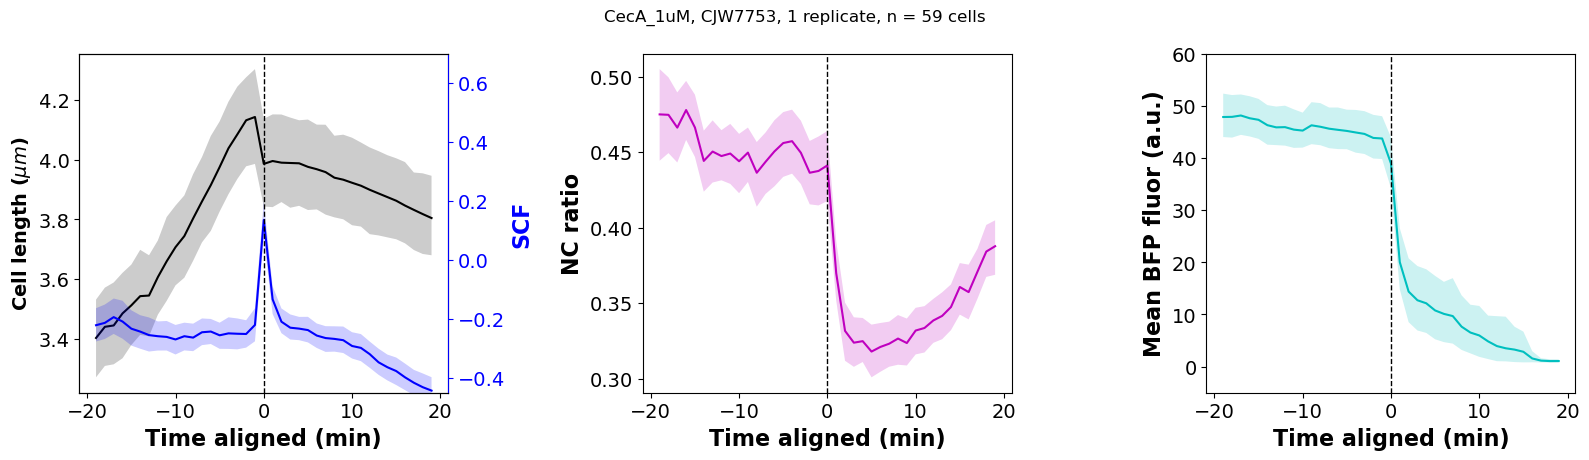

In [22]:

'''Plot ensemble stats'''
AMP_list = [
            'CecA_1uM'
            ]

for k in range(len(AMP_list)):
    AMP_name= AMP_list[k]
    df_temp = df[df['AMP']==AMP_name]
    tp_df_temp = tp_df[tp_df['AMP']==AMP_name]
    t_BFP_loss_mean = np.mean(tp_df_temp['t_BFP_loss_SCF_aligned'])
    t_BFP_loss_sd = np.std(tp_df_temp['t_BFP_loss_SCF_aligned'])
    t_align = 't_align_SCF_f12'
    t_lims = [-20, 20]
    y_SCF = 'SCF'
    
    df_temp = df_temp[(t_lims[0] < df_temp[t_align]) &(df_temp[t_align] < t_lims[1])]

    lw = 1
    fig = plt.figure(figsize=(16, 4.65))
    plt.suptitle('CecA_1uM, CJW7753, 1 replicate'+ ', n = ' + str(len(df_temp['cell_id'].unique())) + ' cells')
    fig.add_subplot(1, 3, 1)
    ax1 = sns.lineplot(data=df_temp, x=t_align, y='cell_length', c = 'black')
    plt.ylabel('Cell length ($\mu m$)', fontsize=14, fontweight='bold')
 

    scf_color = 'blue'

    ax2 = ax1.twinx()
    sns.lineplot(data=df_temp, x=t_align, y=y_SCF, c=scf_color)
    plt.axvline(x=0, linestyle='--', color='black', linewidth=lw)
    plt.ylabel('SCF', fontsize=16, fontweight='bold', color=scf_color)
    plt.ylim(-0.45, 0.7)
    ax1.set_xlabel('Time aligned (min)', fontsize=16, fontweight='bold')
    ax1.tick_params(axis='both', which='major', labelsize=14)
    ax2.tick_params(axis='both', which='major', labelsize=14)
    ax2.tick_params(axis='y', labelcolor=scf_color, color=scf_color)  # blue tick labels + tick marks
    ax2.spines['right'].set_color(scf_color)                          # blue right spine

    for collection in ax1.collections:
        collection.set_edgecolor("none")

    for collection in ax2.collections:
        collection.set_edgecolor("none")

    fig.add_subplot(1, 3, 2)
    ax1 = sns.lineplot(data=df_temp, x=t_align, y='NC_ratio_length',c = 'm')
    plt.ylabel('NC ratio', fontsize=16, fontweight='bold')
    plt.axvline(x=0, linestyle='--', color='black', linewidth=lw)
    ax1.set_xlabel('Time aligned (min)', fontsize=16, fontweight='bold')
    ax1.tick_params(axis='both', which='major', labelsize=14)  # Increase tick label size

    for collection in ax1.collections:
        collection.set_edgecolor("none")

    fig.add_subplot(1, 3, 3)
    ax1 = sns.lineplot(data=df_temp, x=t_align, y='mean_fluor3',c = 'c'
                 )
    plt.ylabel('Mean BFP fluor (a.u.)', fontsize=16, fontweight='bold')

    plt.axvline(x=0, linestyle='--', color='black', linewidth=lw)
    ax1.set_xlabel('Time aligned (min)', fontsize=16, fontweight='bold')
    ax1.tick_params(axis='both', which='major', labelsize=14)  # Increase tick label size
    ax1.set_ylim(-5,60)

    for collection in ax1.collections:
        collection.set_edgecolor("none")
    plt.tight_layout()
    plt.show()

